<a href="https://colab.research.google.com/github/DiabeticRetinopathy114/114_DR/blob/main/APTOS%202019%20Blindness%20Detection/efficientnetb5_150.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

aptos2019_blindness_detection_path = kagglehub.competition_download('aptos2019-blindness-detection')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/aptos2019-blindness-detection/sample_submission.csv
/kaggle/input/aptos2019-blindness-detection/train.csv
/kaggle/input/aptos2019-blindness-detection/test.csv
/kaggle/input/aptos2019-blindness-detection/train_images/ef476be214d4.png
/kaggle/input/aptos2019-blindness-detection/train_images/6dcde47060f9.png
/kaggle/input/aptos2019-blindness-detection/train_images/ec363f48867b.png
/kaggle/input/aptos2019-blindness-detection/train_images/17f6c7072f61.png
/kaggle/input/aptos2019-blindness-detection/train_images/b49b2fac2514.png
/kaggle/input/aptos2019-blindness-detection/train_images/af6166d57f13.png
/kaggle/input/aptos2019-blindness-detection/train_images/8d13c46e7d75.png
/kaggle/input/aptos2019-blindness-detection/train_images/c3b15bf9b4bc.png
/kaggle/input/aptos2019-blindness-detection/train_images/be68322c7223.png
/kaggle/input/aptos2019-blindness-detection/train_images/88e4399d207c.png
/kaggle/input/aptos2019-blindness-detection/train_images/0243404e8a00.png
/kaggle/input

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
from glob import glob
import albumentations as A
from collections import Counter
import warnings
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedShuffleSplit
#from tensorflow.keras.applications import EfficientNetB5
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import Model

warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

class Config:
    IMG_SIZE = 224
    BATCH_SIZE = 32
    EPOCHS = 150
    LEARNING_RATE = 0.001
    PATIENCE = 10
    MIN_LR = 1e-8
    WEIGHT_DECAY = 1e-4
    CLASS_NAMES = ['No_DR', 'Mild', 'Moderate', 'Severe', 'Proliferate_DR']
    NUM_CLASSES = len(CLASS_NAMES)
    DATA_PATH = '/kaggle/input/aptos2019-blindness-detection/train.csv'
    MIN_SAMPLES_PER_CLASS = 800
    MAX_SAMPLES_PER_CLASS = 2000

class CustomAdamW(tf.keras.optimizers.Adam):
    def __init__(self, weight_decay=1e-4, **kwargs):
        super().__init__(**kwargs)
        self.weight_decay = weight_decay

    def _resource_apply_dense(self, grad, var, apply_state=None):
        if self.weight_decay:
            grad += self.weight_decay * var
        return super()._resource_apply_dense(grad, var, apply_state)

class AdvancedAugmentation:
    @staticmethod
    def get_train_augmentation():
        return A.Compose([
            A.HorizontalFlip(p=0.4),
            A.VerticalFlip(p=0.2),
            A.Rotate(limit=15, p=0.5),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.5),
            A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.5),
            A.CLAHE(clip_limit=2.0, p=0.5),
            A.Lambda(image=lambda x, **kwargs: preprocess_input(x))
        ])

    @staticmethod
    def get_val_augmentation():
        return A.Compose([
            A.Lambda(image=lambda x, **kwargs: preprocess_input(x))
        ])

class EnhancedDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, image_paths, labels, batch_size, img_size, augmentation=None, shuffle=True, class_mode='sparse'):
        self.image_paths = image_paths
        self.labels = labels
        self.batch_size = batch_size
        self.img_size = img_size
        self.augmentation = augmentation
        self.shuffle = shuffle
        self.class_mode = class_mode
        self.input_shape = (self.img_size, self.img_size, 3)
        self.indices = np.arange(len(self.image_paths))
        self.on_epoch_end()
        # 移除 image_cache 以避免記憶體問題

    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))

    def __getitem__(self, index):
        indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        batch_paths = [self.image_paths[i] for i in indices]
        batch_labels = [self.labels[i] for i in indices]
        X, y = self._generate_data(batch_paths, batch_labels)
        return X, y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def _load_image(self, path):
        image = cv2.imread(path)
        if image is None:
            return np.zeros((self.img_size, self.img_size, 3), dtype=np.float32)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        return cv2.resize(image, (self.img_size, self.img_size))

    def _generate_data(self, batch_paths, batch_labels):
        actual_batch_size = len(batch_paths)
        X = np.empty((actual_batch_size, *self.input_shape), dtype=np.float32)

        # 自動偵測 label shape
        label_shape = np.shape(batch_labels[0])
        y = np.empty((actual_batch_size, *label_shape), dtype=np.float32)

        for i, (path, label) in enumerate(zip(batch_paths, batch_labels)):
            image = cv2.imread(path)
            if image is None:
                image = np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)
            else:
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                image = cv2.resize(image, (self.img_size, self.img_size))

                # === 加入 Gaussian Filter ===
                sigmaX = 10
                image = cv2.addWeighted(
                    image, 4,
                    cv2.GaussianBlur(image, (0, 0), sigmaX),
                    -4, 128
                )

            if self.augmentation:
                try:
                    augmented = self.augmentation(image=image)
                    image = augmented['image']
                except Exception as e:
                    print(f"資料增強錯誤: {e}")
                    image = preprocess_input(image.astype(np.float32))

            X[i] = image
            y[i] = label  # 直接指派 one-hot 或 sparse label

        return X, y


2025-09-04 06:10:50.072869: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756966250.423170      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756966250.526514      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit
from collections import Counter, defaultdict

def load_dataset(csv_path, img_dir):
    # 固定隨機種子，確保結果可重現
    np.random.seed(42)

    # 讀取 CSV
    df = pd.read_csv(csv_path)  # train.csv
    df['image_path'] = df['id_code'].apply(lambda x: os.path.join(img_dir, f"{x}.png"))
    df['diagnosis'] = df['diagnosis'].astype(int)

    image_paths = df['image_path'].values
    labels = df['diagnosis'].values

    # --- 平衡前報告 ---
    print("原始類別分布:", Counter(labels))

    # 重新平衡各類樣本數
    class_counts = defaultdict(list)
    for i, lbl in enumerate(labels):
        class_counts[lbl].append(image_paths[i])

    balanced_paths, balanced_labels = [], []
    for lbl, paths in class_counts.items():
        paths = np.array(paths)
        count = len(paths)
        target = min(max(Config.MIN_SAMPLES_PER_CLASS, count), Config.MAX_SAMPLES_PER_CLASS)
        if count < target:
            extra = np.random.choice(paths, size=(target - count), replace=True)
            paths = np.concatenate([paths, extra])
        else:
            paths = np.random.choice(paths, size=target, replace=False)
        balanced_paths.extend(paths)
        balanced_labels.extend([lbl] * target)

    balanced_paths, balanced_labels = np.array(balanced_paths), np.array(balanced_labels)

    # --- 平衡後報告 ---
    print("平衡後類別分布:", Counter(balanced_labels))

    # 分割 train / val / test
    sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)  # test set 15%
    for remain_idx, test_idx in sss1.split(balanced_paths, balanced_labels):
        remain_paths, test_paths = balanced_paths[remain_idx], balanced_paths[test_idx]
        remain_labels, test_labels = balanced_labels[remain_idx], balanced_labels[test_idx]

        val_ratio = 0.15 / 0.85  # ≈ 0.1765
        sss2 = StratifiedShuffleSplit(n_splits=1, test_size=val_ratio, random_state=42)
        for train_idx, val_idx in sss2.split(remain_paths, remain_labels):
            train_paths, val_paths = remain_paths[train_idx], remain_paths[val_idx]
            train_labels, val_labels = remain_labels[train_idx], remain_labels[val_idx]

    # --- 各子集報告 ---
    print("\n 資料集分布")
    print("Train:", Counter(train_labels))
    print("Val  :", Counter(val_labels))
    print("Test :", Counter(test_labels))

    return (train_paths, train_labels), (val_paths, val_labels), (test_paths, test_labels)


In [ ]:
train_set, val_set, test_set = load_dataset(
    csv_path="/kaggle/input/aptos2019-blindness-detection/train.csv",
    img_dir="/kaggle/input/aptos2019-blindness-detection/train_images"
)


原始類別分布: Counter({0: 1805, 2: 999, 1: 370, 4: 295, 3: 193})
平衡後類別分布: Counter({0: 1805, 2: 999, 4: 800, 1: 800, 3: 800})

 資料集分布
Train: Counter({0: 1263, 2: 699, 3: 560, 4: 560, 1: 560})
Val  : Counter({0: 271, 2: 150, 3: 120, 1: 120, 4: 120})
Test : Counter({0: 271, 2: 150, 4: 120, 1: 120, 3: 120})


In [ ]:
import pandas as pd

def quick_balance_report_from_csv(csv_path):
    """快速查看 APTOS2019 (train.csv) 類別數量與平衡效果"""
    df = pd.read_csv(csv_path)
    df['diagnosis'] = df['diagnosis'].astype(int)

    print("APTOS2019 資料平衡快速報告")
    print("=" * 50)

    for idx, cls in enumerate(Config.CLASS_NAMES):
        count = (df['diagnosis'] == idx).sum()
        target = min(max(Config.MIN_SAMPLES_PER_CLASS, count), Config.MAX_SAMPLES_PER_CLASS)

        if count < target:
            status = f"➕ 複製到 {target:,}"
        elif count > target:
            status = f"➖ 減少到 {target:,}"
        else:
            status = "保持不變"

        print(f"{cls:<15}: {count:>6,} → {status}")


In [ ]:
quick_balance_report_from_csv("/kaggle/input/aptos2019-blindness-detection/train.csv")


APTOS2019 資料平衡快速報告
No_DR          :  1,805 → 保持不變
Mild           :    370 → ➕ 複製到 800
Moderate       :    999 → 保持不變
Severe         :    193 → ➕ 複製到 800
Proliferate_DR :    295 → ➕ 複製到 800


In [ ]:
from tensorflow.keras.applications import EfficientNetB5
from tensorflow.keras import layers, Model

def create_model(input_shape, num_classes):
    base_model = EfficientNetB5(weights='imagenet', include_top=False, input_shape=input_shape, name="efficientnetb5")
    base_model.trainable = True  # 若要先 freeze，這裡改為 False

    inputs = tf.keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)  # BatchNorm 在 Inference 模式
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs)

In [ ]:
def main():
    # === 載入資料 ===
    (train_paths, train_labels), (val_paths, val_labels), (test_paths, test_labels) = load_dataset(
    csv_path=Config.DATA_PATH,
    img_dir="/kaggle/input/aptos2019-blindness-detection/train_images"
    )


    # One-hot 編碼（因為 loss 使用 CategoricalCrossentropy）
    train_labels = tf.keras.utils.to_categorical(train_labels, num_classes=Config.NUM_CLASSES)
    val_labels = tf.keras.utils.to_categorical(val_labels, num_classes=Config.NUM_CLASSES)
    test_labels = tf.keras.utils.to_categorical(test_labels, num_classes=Config.NUM_CLASSES)

    # === 資料增強器 ===
    train_aug = AdvancedAugmentation.get_train_augmentation()
    val_aug = AdvancedAugmentation.get_val_augmentation()

    # === 資料產生器 ===
    train_gen = EnhancedDataGenerator(train_paths, train_labels, Config.BATCH_SIZE, Config.IMG_SIZE, train_aug)
    val_gen = EnhancedDataGenerator(val_paths, val_labels, Config.BATCH_SIZE, Config.IMG_SIZE, val_aug)
    test_gen = EnhancedDataGenerator(test_paths, test_labels, Config.BATCH_SIZE, Config.IMG_SIZE, val_aug)

    # === 建立模型 ===
    model = create_model((Config.IMG_SIZE, Config.IMG_SIZE, 3), Config.NUM_CLASSES)

    # === Warm-up 階段：只訓練上層分類器 ===
    model.get_layer('efficientnetb5').trainable = False
    model.compile(
        optimizer=CustomAdamW(learning_rate=1e-3, weight_decay=Config.WEIGHT_DECAY),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )

    print("Warm-up training (frozen base)...")
    history_warmup = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=5,
        callbacks=[
            tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3),
        ]
    )

    # === Fine-tuning 階段：解凍整個模型 ===
    model.get_layer('efficientnetb5').trainable = True
    model.compile(
        optimizer=CustomAdamW(learning_rate=1e-5, weight_decay=Config.WEIGHT_DECAY),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )

    print("Fine-tuning full model...")
    history_finetune = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=Config.EPOCHS,
        initial_epoch=5,  # 從第5 epoch接續
        callbacks=[
            tf.keras.callbacks.ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True),
            tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=Config.MIN_LR),
            tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=Config.PATIENCE, restore_best_weights=True),
        ]
    )

    # 回傳模型與 history（可以選擇合併兩段 history）
    return model, (history_warmup, history_finetune)

In [ ]:
def merge_history(h1, h2):
    merged = {}
    for k in h1:
        merged[k] = h1[k] + h2[k]
    return merged
model, (h1, h2) = main()
history = merge_history(h1.history, h2.history)

原始類別分布: Counter({0: 1805, 2: 999, 1: 370, 4: 295, 3: 193})
平衡後類別分布: Counter({0: 1805, 2: 999, 4: 800, 1: 800, 3: 800})

 資料集分布
Train: Counter({0: 1263, 2: 699, 3: 560, 4: 560, 1: 560})
Val  : Counter({0: 271, 2: 150, 3: 120, 1: 120, 4: 120})
Test : Counter({0: 271, 2: 150, 4: 120, 1: 120, 3: 120})


I0000 00:00:1756966274.888447      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1756966274.889179      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


115263384/115263384 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Warm-up training (frozen base)...
Epoch 1/5


I0000 00:00:1756966326.447748     102 service.cc:148] XLA service 0x7861f805c910 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1756966326.449425     102 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1756966326.449446     102 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1756966331.370831     102 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/114 ━━━━━━━━━━━━━━━━━━━━ 2:02:34 65s/step - accuracy: 0.1562 - loss: 1.6644

...

114/114 ━━━━━━━━━━━━━━━━━━━━ 642s 5s/step - accuracy: 0.4747 - loss: 1.3514 - val_accuracy: 0.6031 - val_loss: 1.0714 - learning_rate: 0.0010
Epoch 2/5
114/114 ━━━━━━━━━━━━━━━━━━━━ 504s 4s/step - accuracy: 0.5664 - loss: 1.1626 - val_accuracy: 0.6569 - val_loss: 1.0382 - learning_rate: 0.0010
Epoch 3/5
114/114 ━━━━━━━━━━━━━━━━━━━━ 507s 4s/step - accuracy: 0.6179 - loss: 1.0882 - val_accuracy: 0.6773 - val_loss: 0.9947 - learning_rate: 0.0010
Epoch 4/5
114/114 ━━━━━━━━━━━━━━━━━━━━ 498s 4s/step - accuracy: 0.6468 - loss: 1.0459 - val_accuracy: 0.6965 - val_loss: 0.9666 - learning_rate: 0.0010
Epoch 5/5
114/114 ━━━━━━━━━━━━━━━━━━━━ 500s 4s/step - accuracy: 0.6461 - loss: 1.0523 - val_accuracy: 0.6825 - val_loss: 0.9725 - learning_rate: 0.0010
Fine-tuning full model...
Epoch 6/150


E0000 00:00:1756969117.907769     103 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1756969118.049751     103 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1756969118.489840     103 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1756969118.635981     103 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1756969119.049273     103 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:0

 46/114 ━━━━━━━━━━━━━━━━━━━━ 4:02 4s/step - accuracy: 0.4663 - loss: 1.4639

E0000 00:00:1756969354.164316     103 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1756969354.303488     103 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1756969354.441080     103 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1756969354.782169     103 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1756969354.926142     103 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:0

114/114 ━━━━━━━━━━━━━━━━━━━━ 805s 5s/step - accuracy: 0.4714 - loss: 1.4314 - val_accuracy: 0.6492 - val_loss: 1.0505 - learning_rate: 1.0000e-05
Epoch 7/150
114/114 ━━━━━━━━━━━━━━━━━━━━ 503s 4s/step - accuracy: 0.5431 - loss: 1.2320 - val_accuracy: 0.6620 - val_loss: 1.0335 - learning_rate: 1.0000e-05
Epoch 8/150
114/114 ━━━━━━━━━━━━━━━━━━━━ 505s 4s/step - accuracy: 0.5867 - loss: 1.1595 - val_accuracy: 0.6697 - val_loss: 0.9993 - learning_rate: 1.0000e-05
Epoch 9/150
114/114 ━━━━━━━━━━━━━━━━━━━━ 500s 4s/step - accuracy: 0.6112 - loss: 1.1097 - val_accuracy: 0.6825 - val_loss: 0.9725 - learning_rate: 1.0000e-05
Epoch 10/150
114/114 ━━━━━━━━━━━━━━━━━━━━ 502s 4s/step - accuracy: 0.6254 - loss: 1.0914 - val_accuracy: 0.6825 - val_loss: 0.9542 - learning_rate: 1.0000e-05
Epoch 11/150
114/114 ━━━━━━━━━━━━━━━━━━━━ 507s 4s/step - accuracy: 0.6637 - loss: 1.0392 - val_accuracy: 0.7055 - val_loss: 0.9305 - learning_rate: 1.0000e-05
Epoch 12/150
114/114 ━━━━━━━━━━━━━━━━━━━━ 507s 4s/step - accur

In [ ]:
def plot_training_history(history):
    """繪製訓練歷史圖表"""
    plt.figure(figsize=(12, 5))




    # Loss 折線圖

    plt.subplot(1, 2, 1)
    plt.plot(history['loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title('Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Accuracy 折線圖
    plt.subplot(1, 2, 2)
    plt.plot(history['accuracy'], label='Train Accuracy')
    plt.plot(history['val_accuracy'], label='Val Accuracy')
    plt.title('Accuracy Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

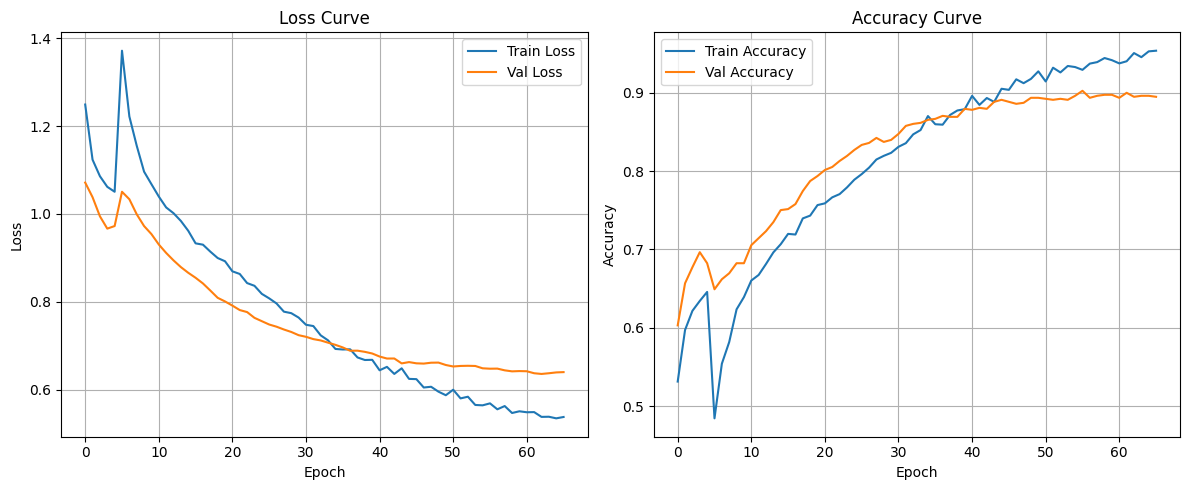

In [ ]:
plot_training_history(history)

原始類別分布: Counter({0: 1805, 2: 999, 1: 370, 4: 295, 3: 193})
平衡後類別分布: Counter({0: 1805, 2: 999, 4: 800, 1: 800, 3: 800})

 資料集分布
Train: Counter({0: 1263, 2: 699, 3: 560, 4: 560, 1: 560})
Val  : Counter({0: 271, 2: 150, 3: 120, 1: 120, 4: 120})
Test : Counter({0: 271, 2: 150, 4: 120, 1: 120, 3: 120})
25/25 ━━━━━━━━━━━━━━━━━━━━ 87s 3s/step

Overall ROC-AUC: 0.9893

=== Classification Metrics (Test Set) ===

                precision    recall  f1-score     support  sensitivity  \
No_DR            0.992537  0.981550  0.987013  271.000000     0.981550   
Mild             0.828358  0.925000  0.874016  120.000000     0.925000   
Moderate         0.873134  0.780000  0.823944  150.000000     0.780000   
Severe           0.936000  0.975000  0.955102  120.000000     0.975000   
Proliferate_DR   0.891667  0.891667  0.891667  120.000000     0.891667   
accuracy         0.919334  0.919334  0.919334    0.919334          NaN   
macro avg        0.904339  0.910643  0.906348  781.000000     0.910643   
w

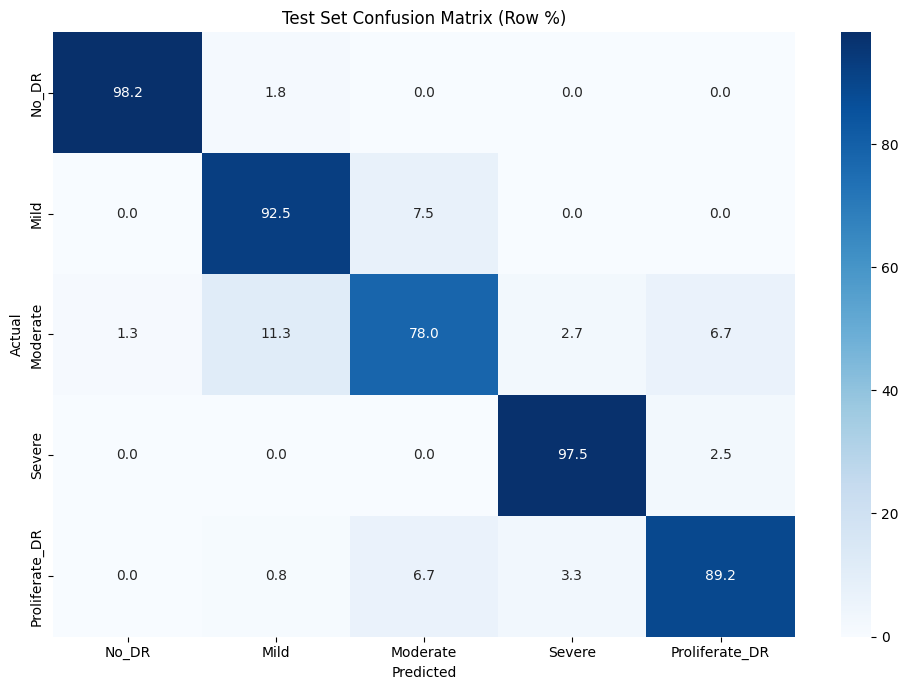

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# # === 訓練模型 ===
# model, (history_warmup, history_finetune) = main()

# === 使用 validation augmentation 評估測試集 ===
val_aug = AdvancedAugmentation.get_val_augmentation()
(_, _), (_, _), (test_paths, test_labels_raw) = load_dataset(
    csv_path=Config.DATA_PATH,
    img_dir="/kaggle/input/aptos2019-blindness-detection/train_images"
    # csv_path=Config.CSV_PATH,        # e.g. "trainLabels.csv"
    # img_dir=Config.DATA_PATH         # e.g. "train_images" 資料夾
)

test_gen = EnhancedDataGenerator(
    test_paths,
    tf.keras.utils.to_categorical(test_labels_raw, num_classes=Config.NUM_CLASSES),
    Config.BATCH_SIZE, Config.IMG_SIZE,
    val_aug, shuffle=False
)

# === 模型預測 ===
y_probs = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_probs, axis=1)
y_true = test_labels_raw  # 注意：用 raw label，不是 one-hot

# === 分類報告 ===
report_dict = classification_report(
    y_true, y_pred,
    target_names=Config.CLASS_NAMES,
    output_dict=True
)
metrics_df = pd.DataFrame(report_dict).T

# === 混淆矩陣 ===
cm = confusion_matrix(y_true, y_pred)

# Sensitivity (Recall) 與 Specificity
sensitivity_per_class = np.diag(cm) / cm.sum(axis=1)
specificity_per_class = []
for i in range(len(Config.CLASS_NAMES)):
    tn = np.sum(np.delete(np.delete(cm, i, axis=0), i, axis=1))
    fp = np.sum(np.delete(cm, i, axis=0)[:, i])
    specificity_per_class.append(tn / (tn + fp))

# 寫入 DataFrame
metrics_df.loc[Config.CLASS_NAMES, "sensitivity"] = sensitivity_per_class
metrics_df.loc[Config.CLASS_NAMES, "specificity"] = specificity_per_class
metrics_df.loc["macro avg", ["sensitivity", "specificity"]] = [
    np.mean(sensitivity_per_class), np.mean(specificity_per_class)
]
metrics_df.loc["weighted avg", ["sensitivity", "specificity"]] = [
    np.average(sensitivity_per_class, weights=cm.sum(axis=1)),
    np.average(specificity_per_class, weights=cm.sum(axis=1))
]

# === ROC-AUC ===
try:
    auc = roc_auc_score(y_true, y_probs, multi_class="ovr")
    print(f"\nOverall ROC-AUC: {auc:.4f}")
except Exception as e:
    print("ROC-AUC not computed:", e)

# === 輸出表格 ===
print("\n=== Classification Metrics (Test Set) ===\n")
print(metrics_df)

# 換算成百分比（每一列 = 100%）
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# 繪製百分比混淆矩陣
plt.figure(figsize=(10, 7))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=Config.CLASS_NAMES,
            yticklabels=Config.CLASS_NAMES)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Test Set Confusion Matrix (Row %)")
plt.tight_layout()
plt.show()

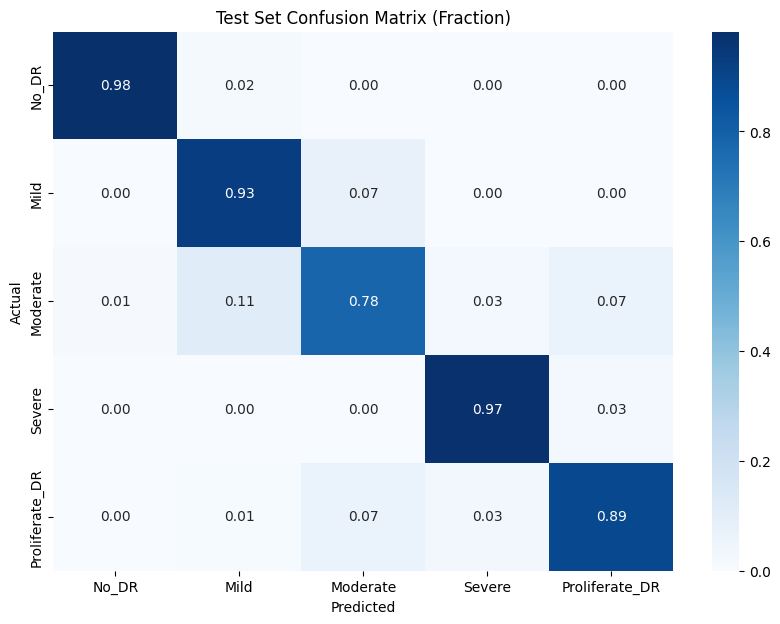

In [ ]:
# === 繪製小數比例混淆矩陣 ===
cm_fraction = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 7))
sns.heatmap(cm_fraction, annot=True, fmt=".2f", cmap='Blues',
            xticklabels=Config.CLASS_NAMES,
            yticklabels=Config.CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Test Set Confusion Matrix (Fraction)")
plt.show()



In [ ]:

model.save('model_efficientnetb5.h5')